# DuckDB Workbench

This notebook is used for exploring the project data through DuckDB and Polars. It assumes `uv run python src/load_duckdb.py` has already been run so the current Parquet outputs are exposed as DuckDB views.

In [31]:
from pathlib import Path

import duckdb
import polars as pl

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "data" / "duckdb" / "fandom.duckdb"

con = duckdb.connect(str(DB_PATH))


def q(sql: str) -> pl.DataFrame:
    return con.sql(sql).pl()


print({"db_path": str(DB_PATH), "exists": DB_PATH.exists()})

{'db_path': '/home/dmika/code/fandom-project/data/duckdb/fandom.duckdb', 'exists': True}


## All Available Views


In [32]:
tables_df = q("""
select table_name
from information_schema.tables
where table_schema = 'main'
order by table_name
""")

tables_df

table_name
str
"""youtube_comments"""
"""youtube_query_results"""
"""youtube_user_ip_activity"""
"""youtube_user_video_map"""
"""youtube_users"""
"""youtube_video_query_map"""
"""youtube_videos"""


## Quick Video Queries

These first queries are useful for checking how many videos were collected per IP, which queries surfaced them, and which titles have the highest comment counts.

In [33]:
q("""
select
    ip_name,
    count(*) as videos,
    avg(comment_count) as avg_comment_count,
    max(comment_count) as max_comment_count
from youtube_videos
group by ip_name
order by videos desc
""")

ip_name,videos,avg_comment_count,max_comment_count
str,i64,f64,i64
"""Star Wars""",203,3239.960591,113178
"""Warhammer 40K""",190,1547.047368,18988
"""Dungeons & Dragons""",173,2861.491329,43162
"""Marvel""",121,13080.338843,453519
"""Pokemon""",118,2210.627119,18184
"""Harry Potter""",114,3161.412281,42494


## Comment Count by IP

This plot shows the total collected comment count by IP using the current `youtube_videos` table.

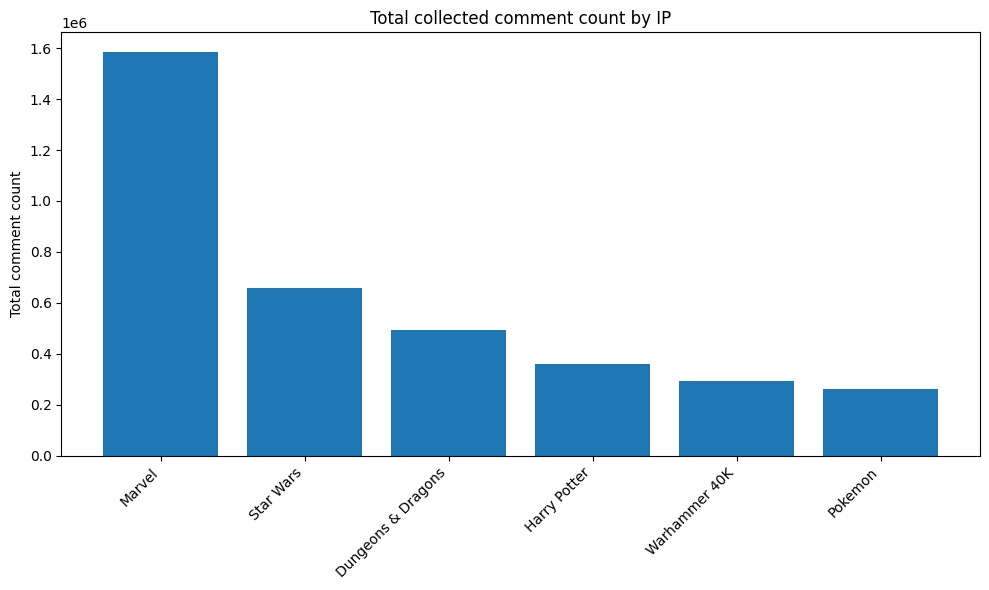

ip_name,total_comment_count
str,"decimal[38,0]"
"""Marvel""",1582721
"""Star Wars""",657712
"""Dungeons & Dragons""",495038
"""Harry Potter""",360401
"""Warhammer 40K""",293939
"""Pokemon""",260854


In [34]:
import matplotlib.pyplot as plt

comment_count_by_ip = q("""
select
    ip_name,
    sum(comment_count) as total_comment_count
from youtube_videos
group by ip_name
order by total_comment_count desc
""")

plot_df = comment_count_by_ip.to_pandas()

plt.figure(figsize=(10, 6))
plt.bar(plot_df["ip_name"], plot_df["total_comment_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total comment count")
plt.title("Total collected comment count by IP")
plt.tight_layout()
plt.show()

comment_count_by_ip

In [35]:
q("""
select
    ip_name,
    video_id,
    title,
    comment_count,
    view_count,
    matched_queries
from youtube_videos
order by comment_count desc, view_count desc
limit 25
""")

ip_name,video_id,title,comment_count,view_count,matched_queries
str,str,str,i64,i64,str
"""Marvel""","""6ZfuNTqbHE8""","""Marvel Studios' Avengers: Infi…",453519,270577120,"""Avengers"""
"""Marvel""","""hA6hldpSTF8""","""Marvel Studios' Avengers - Off…",272090,111514906,"""Avengers"""
"""Marvel""","""TcMBFSGVi1c""","""Marvel Studios' Avengers: Endg…",261719,166891065,"""Avengers"""
"""Star Wars""","""sGbxmsDFVnE""","""Star Wars: The Force Awakens T…",113178,112430712,"""Star Wars | new star wars"""
"""Marvel""","""eOrNdBpGMv8""","""Marvel's The Avengers- Trailer…",45842,39927430,"""Avengers"""
…,…,…,…,…,…
"""Star Wars""","""HnzNZ0Mdx4I""","""Ahsoka | Teaser Trailer | Disn…",26537,16702784,"""Ahsoka"""
"""Dungeons & Dragons""","""OQx7q6mwkV4""","""My First Time Playing DUNGEONS…",25115,13239407,"""Dungeons and Dragons | DND act…"
"""Marvel""","""1clWprLC5Ak""","""Thor Will Return | Avengers: D…",24633,20956387,"""Marvel | Avengers"""


## User-to-Video Structure

This is the graph-like part of the data model. Users connect to videos through comments, and videos connect back to IPs and queries.

In [36]:
q("""
select
    c.commenter_id,
    c.commenter_name,
    c.video_id,
    v.ip_name,
    v.title,
    count(*) as comments_left
from youtube_comments c
join youtube_videos v using (video_id)
where c.commenter_id is not null and c.commenter_id != ''
group by 1, 2, 3, 4, 5
order by comments_left desc
limit 25
""")

commenter_id,commenter_name,video_id,ip_name,title,comments_left
str,str,str,str,str,i64
"""UCSXBdbfLV9EwEIl4Jtm_v3Q""","""@emmon5377""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",363
"""UCH7RI2o52yBPuBwoSttK_XA""","""@ChristianFitterling-vv5zl""","""sGbxmsDFVnE""","""Star Wars""","""Star Wars: The Force Awakens T…",252
"""UCyGWAwmmHNZnrZSehTHC1jw""","""@stevevadeboncoeur3903""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",235
"""UCVdBFSveXWjIMETfykEIpsw""","""@drednaut5052""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",200
"""UC4RI7lYMZroXOGXefBRjtdA""","""@tokyspark4798""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",107
…,…,…,…,…,…
"""UCbwDA5UL75UM6liAJTRu1eg""","""@takerhulk3163""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",27
"""UC5Sw3Xy3ijLtVYUCo9gbcoQ""","""@Haleemababu""","""399Ez7WHK5s""","""Marvel""","""Avengers: Doomsday | Only in T…",25
"""UCHrNnSglKkF_0Jj3JDanDZQ""","""@windso878""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",24


In [37]:
q("""
select
    commenter_id,
    commenter_name,
    count(distinct video_id) as unique_videos,
    count(distinct ip_name) as unique_ips,
    sum(total_comments) as total_comments
from youtube_user_video_map
group by 1, 2
having count(distinct video_id) > 1
order by unique_videos desc, total_comments desc
limit 25
""")

commenter_id,commenter_name,unique_videos,unique_ips,total_comments
str,str,i64,i64,"decimal[38,0]"
"""UCRWKz5YYl24Ag7dZXHWLncg""","""@anasshahid224""",17,4,17
"""UCnAgfUY_t9QSo0eitqGouZg""","""@Dantalu5""",16,3,29
"""UCsqSnv0CUn1iPoW5bbl0j2g""","""@JnEricsonx""",15,2,33
"""UCRINMC-GoWeUK-qpCqssuHw""","""@arthurchallat8530""",14,2,22
"""UCeW9-7L0bNjLQfsZJEptZYQ""","""@scorpioslut8385""",14,1,17
…,…,…,…,…
"""UCCmboOTjRxDA96biTRRSMPA""","""@rithrius5384""",12,3,13
"""UCE63ti1OCP5oh_GZ2DYF2rA""","""@jackfromyourhouse6033""",12,1,13
"""UCTVEYCOFPyFQv4s4lrb0kew""","""@BigBWolf90""",12,2,13


## Polars exploration



In [38]:
videos_df = q("select * from youtube_videos")
comments_df = q("select * from youtube_comments")

videos_df.group_by("ip_name").agg(
    pl.len().alias("videos"),
    pl.col("comment_count").mean().alias("avg_comment_count"),
    pl.col("view_count").mean().alias("avg_view_count"),
).sort("videos", descending=True)

ip_name,videos,avg_comment_count,avg_view_count
str,u32,f64,f64
"""Star Wars""",203,3239.960591,6.7458e6
"""Warhammer 40K""",190,1547.047368,1.7084e6
"""Dungeons & Dragons""",173,2861.491329,3.3403e6
"""Marvel""",121,13080.338843,1.8271e7
"""Pokemon""",118,2210.627119,3.7252e6
"""Harry Potter""",114,3161.412281,4.7543e6


## Shared Commenter Overlap Heatmap

This is the key analysis, we measure overlap at the IP level by following the path `commenter_id -> video_id -> ip_name`. In practice, we use `youtube_user_ip_activity`, which already tells us which commenter ids appeared in which IPs, then compute shared commenters across IP pairs with Polars before plotting the heatmap with seaborn and matplotlib.

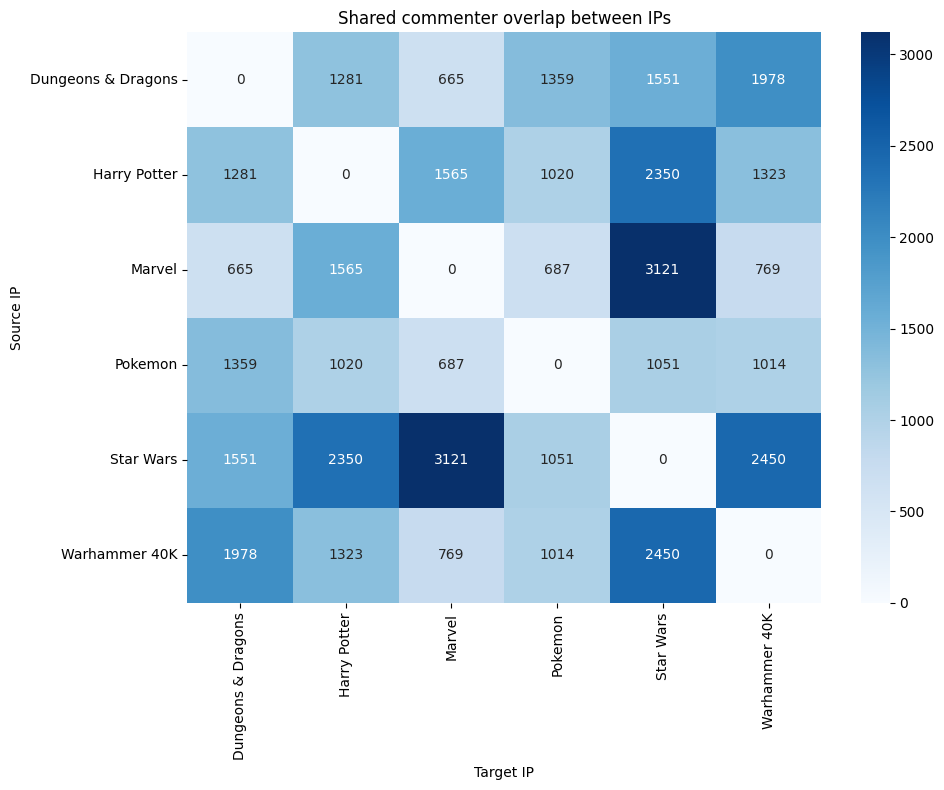

source_ip,target_ip,shared_commenters
str,str,u32
"""Marvel""","""Star Wars""",3121
"""Star Wars""","""Warhammer 40K""",2450
"""Harry Potter""","""Star Wars""",2350
"""Dungeons & Dragons""","""Warhammer 40K""",1978
"""Harry Potter""","""Marvel""",1565
…,…,…
"""Harry Potter""","""Pokemon""",1020
"""Pokemon""","""Warhammer 40K""",1014
"""Marvel""","""Warhammer 40K""",769


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

user_ip_df = q("select commenter_id, ip_name from youtube_user_ip_activity")

commenter_ip = (
    user_ip_df
    .filter(pl.col("commenter_id").is_not_null() & (pl.col("commenter_id") != ""))
    .unique()
)

ip_order = commenter_ip.select("ip_name").unique().sort("ip_name")["ip_name"].to_list()

pair_overlap_df = (
    commenter_ip.rename({"ip_name": "source_ip"})
    .join(commenter_ip.rename({"ip_name": "target_ip"}), on="commenter_id", how="inner")
    .filter(pl.col("source_ip") < pl.col("target_ip"))
    .group_by(["source_ip", "target_ip"])
    .agg(pl.len().alias("shared_commenters"))
    .sort(["shared_commenters", "source_ip", "target_ip"], descending=[True, False, False])
)

heatmap_rows = []
for source_ip in ip_order:
    for target_ip in ip_order:
        if source_ip == target_ip:
            heatmap_rows.append({
                "source_ip": source_ip,
                "target_ip": target_ip,
                "shared_commenters": 0,
            })
        else:
            left_ip = min(source_ip, target_ip)
            right_ip = max(source_ip, target_ip)
            match = pair_overlap_df.filter(
                (pl.col("source_ip") == left_ip) & (pl.col("target_ip") == right_ip)
            )
            shared = match[0, "shared_commenters"] if match.height > 0 else 0
            heatmap_rows.append({
                "source_ip": source_ip,
                "target_ip": target_ip,
                "shared_commenters": shared,
            })

heatmap_df = pl.DataFrame(heatmap_rows)
heatmap_pd = heatmap_df.to_pandas().pivot(
    index="source_ip",
    columns="target_ip",
    values="shared_commenters",
).loc[ip_order, ip_order]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_pd, annot=True, fmt=".0f", cmap="Blues")
plt.title("Shared commenter overlap between IPs")
plt.xlabel("Target IP")
plt.ylabel("Source IP")
plt.tight_layout()
plt.show()

pair_overlap_df

## Videos With The Most Cross-IP Users

This view ranks videos by how many distinct commenters on that video also appear in more than one IP overall. In other words, it highlights the videos that contribute the most to cross-IP overlap in the commenter graph.

In [40]:
import pandas as pd
from IPython.display import display

pretty_cross_ip_video_table = (
    cross_ip_video_overlap_df
    .select([
        pl.col("ip_name").alias("IP"),
        pl.col("title").alias("Video Title"),
        pl.col("cross_ip_commenters").alias("Cross-IP Commenters"),
        pl.col("distinct_commenters_on_video").alias("Distinct Commenters On Video"),
        pl.col("cross_ip_commenter_share").alias("Cross-IP Share"),
    ])
    .to_pandas()
)

pd.set_option("display.max_colwidth", None)

styled_cross_ip_video_table = (
    pretty_cross_ip_video_table.style
    .hide(axis="index")
    .format({
        "Cross-IP Commenters": "{:,.0f}",
        "Distinct Commenters On Video": "{:,.0f}",
        "Cross-IP Share": "{:.1%}",
    })
    .set_properties(subset=["Video Title"], **{"text-align": "left", "white-space": "normal"})
    .set_properties(subset=["IP"], **{"text-align": "left"})
    .set_caption("Top videos ranked by distinct commenters who also appear in multiple IPs")
)

display(styled_cross_ip_video_table)

IP,Video Title,Cross-IP Commenters,Distinct Commenters On Video,Cross-IP Share
Marvel,Avengers Doomsday Will Make Or Break The MCU,852,"3,878",22.0%
Harry Potter,Harry Potter - Here We Go Again...,621,"3,826",16.2%
Star Wars,"Ahsoka - Bad Writing, Pandering And Wasted Potential",577,"3,831",15.1%
Star Wars,The Mandalorian and Grogu | Official Trailer | In Theaters May 22,568,"3,849",14.8%
Star Wars,Star Wars: Fate of the Old Republic Teaser Trailer,562,"3,930",14.3%
Harry Potter,The Harry Potter Show is DOOMED - HBO PANICS!,546,"3,744",14.6%
Dungeons & Dragons,Dungeons & Dragons: Honor Among Thieves | Official Trailer (2023 Movie),544,"3,797",14.3%
Star Wars,Andor - The Best Show At The Worst Time,536,"3,880",13.8%
Star Wars,"The Mandalorian and Grogu | Official Trailer | In Theaters May 22, 2026",523,"3,868",13.5%
Star Wars,Star Wars: Maul - Shadow Lord | Official Teaser Trailer | Streaming April 6 on Disney+,522,"3,861",13.5%


## Video-Video Similarity Based On Shared Commenters

This view ranks pairs of videos from different IPs by how many distinct commenters they share. It uses one row per `(commenter_id, video_id)` so repeated comments do not inflate similarity, and it also computes Jaccard similarity to contextualize raw overlap.

In [43]:
import pandas as pd
from IPython.display import display

video_metadata_similarity_df = (
    q("""
    select ip_name, video_id, title
    from youtube_videos
    """)
    .unique(subset=["ip_name", "video_id"])
    .with_columns(
        (pl.col("ip_name") + " | " + pl.col("video_id")).alias("video_pair_key")
    )
)

commenter_video_df = (
    q("""
    select commenter_id, video_id, ip_name
    from youtube_user_video_map
    where commenter_id is not null and commenter_id != ''
    """)
    .unique(subset=["commenter_id", "video_id"])
    .join(video_metadata_similarity_df, on=["ip_name", "video_id"], how="left")
)

video_size_df = (
    commenter_video_df
    .group_by(["ip_name", "video_id", "title", "video_pair_key"])
    .agg(pl.n_unique("commenter_id").alias("distinct_commenters"))
)

video_pair_similarity_df = (
    commenter_video_df.rename({
        "ip_name": "left_ip",
        "video_id": "left_video_id",
        "title": "left_title",
        "video_pair_key": "left_pair_key",
    })
    .join(
        commenter_video_df.rename({
            "ip_name": "right_ip",
            "video_id": "right_video_id",
            "title": "right_title",
            "video_pair_key": "right_pair_key",
        }),
        on="commenter_id",
        how="inner",
    )
    .filter(pl.col("left_pair_key") < pl.col("right_pair_key"))
    .filter(pl.col("left_ip") != pl.col("right_ip"))
    .group_by([
        "left_ip",
        "left_video_id",
        "left_title",
        "left_pair_key",
        "right_ip",
        "right_video_id",
        "right_title",
        "right_pair_key",
    ])
    .agg(pl.n_unique("commenter_id").alias("shared_commenters"))
    .join(
        video_size_df.rename({
            "ip_name": "left_ip",
            "video_id": "left_video_id",
            "title": "left_title",
            "video_pair_key": "left_pair_key",
            "distinct_commenters": "left_distinct_commenters",
        }),
        on=["left_ip", "left_video_id", "left_title", "left_pair_key"],
        how="left",
    )
    .join(
        video_size_df.rename({
            "ip_name": "right_ip",
            "video_id": "right_video_id",
            "title": "right_title",
            "video_pair_key": "right_pair_key",
            "distinct_commenters": "right_distinct_commenters",
        }),
        on=["right_ip", "right_video_id", "right_title", "right_pair_key"],
        how="left",
    )
    .with_columns([
        (
            pl.col("left_distinct_commenters")
            + pl.col("right_distinct_commenters")
            - pl.col("shared_commenters")
        ).alias("commenter_union"),
    ])
    .with_columns([
        (pl.col("shared_commenters") / pl.col("commenter_union")).round(3).alias("jaccard_similarity"),
    ])
    .sort(
        ["shared_commenters", "jaccard_similarity"],
        descending=[True, True],
    )
    .head(10)
)

pretty_video_pair_similarity_table = (
    video_pair_similarity_df
    .select([
        pl.col("left_ip").alias("Left IP"),
        pl.col("left_title").alias("Left Video"),
        pl.col("right_ip").alias("Right IP"),
        pl.col("right_title").alias("Right Video"),
        pl.col("shared_commenters").alias("Shared Commenters"),
        pl.col("jaccard_similarity").alias("Jaccard Similarity"),
    ])
    .to_pandas()
)

pd.set_option("display.max_colwidth", None)

styled_video_pair_similarity_table = (
    pretty_video_pair_similarity_table.style
    .hide(axis="index")
    .format({
        "Shared Commenters": "{:,.0f}",
        "Jaccard Similarity": "{:.1%}",
    })
    .set_properties(subset=["Left IP", "Right IP"], **{"text-align": "left"})
    .set_properties(
        subset=["Left Video", "Right Video"],
        **{"text-align": "left", "white-space": "normal"},
    )
    .set_caption("Top 10 cross-IP video pairs ranked by shared commenters")
)

display(styled_video_pair_similarity_table)

video_pair_similarity_df

Left IP,Left Video,Right IP,Right Video,Shared Commenters,Jaccard Similarity
Harry Potter,Harry Potter - Here We Go Again...,Marvel,Avengers Doomsday Will Make Or Break The MCU,113,1.5%
Harry Potter,The Harry Potter Show is DOOMED - HBO PANICS!,Marvel,Avengers Doomsday Will Make Or Break The MCU,113,1.5%
Marvel,Avengers Doomsday Will Make Or Break The MCU,Star Wars,Andor - The Best Show At The Worst Time,100,1.3%
Marvel,Avengers Doomsday Will Make Or Break The MCU,Star Wars,"Ahsoka - Bad Writing, Pandering And Wasted Potential",98,1.3%
Harry Potter,Harry Potter e a Pedra Filosofal | Teaser Oficial | HBO Max,Marvel,Homem-Aranha: Um Novo Dia | Trailer Oficial Dublado,61,0.8%
Marvel,Marvel Television’s Wonder Man | Official Trailer,Star Wars,The Mandalorian and Grogu | Official Trailer | In Theaters May 22,61,0.8%
Harry Potter,Harry Potter - Here We Go Again...,Star Wars,"Ahsoka - Bad Writing, Pandering And Wasted Potential",58,0.8%
Harry Potter,Hogwarts Legacy - Before You Buy,Pokemon,Pokemon Scarlet & Violet - Before You Buy,55,0.9%
Harry Potter,Harry Potter e a Pedra Filosofal | Teaser Oficial | HBO Max,Marvel,Vingadores: Doutor Destino | Teaser Oficial,49,0.8%
Marvel,Avengers Doomsday Will Make Or Break The MCU,Star Wars,"The Mandalorian and Grogu | Official Trailer | In Theaters May 22, 2026",49,0.6%


left_ip,left_video_id,left_title,left_pair_key,right_ip,right_video_id,right_title,right_pair_key,shared_commenters,left_distinct_commenters,right_distinct_commenters,commenter_union,jaccard_similarity
str,str,str,str,str,str,str,str,u32,u32,u32,u32,f64
"""Harry Potter""","""teeGwtLa0FI""","""Harry Potter - Here We Go Agai…","""Harry Potter | teeGwtLa0FI""","""Marvel""","""LR09_utgjXc""","""Avengers Doomsday Will Make Or…","""Marvel | LR09_utgjXc""",113,3826,3878,7591,0.015
"""Harry Potter""","""oFJTt6tFrOk""","""The Harry Potter Show is DOOME…","""Harry Potter | oFJTt6tFrOk""","""Marvel""","""LR09_utgjXc""","""Avengers Doomsday Will Make Or…","""Marvel | LR09_utgjXc""",113,3744,3878,7509,0.015
"""Marvel""","""LR09_utgjXc""","""Avengers Doomsday Will Make Or…","""Marvel | LR09_utgjXc""","""Star Wars""","""pPhEsoSAhvY""","""Andor - The Best Show At The W…","""Star Wars | pPhEsoSAhvY""",100,3878,3880,7658,0.013
"""Marvel""","""LR09_utgjXc""","""Avengers Doomsday Will Make Or…","""Marvel | LR09_utgjXc""","""Star Wars""","""cFgErWIJ7HY""","""Ahsoka - Bad Writing, Panderin…","""Star Wars | cFgErWIJ7HY""",98,3878,3831,7611,0.013
"""Harry Potter""","""wYWggSuxwIo""","""Harry Potter e a Pedra Filosof…","""Harry Potter | wYWggSuxwIo""","""Marvel""","""PlulyWs1kS4""","""Homem-Aranha: Um Novo Dia | Tr…","""Marvel | PlulyWs1kS4""",61,3840,3829,7608,0.008
"""Marvel""","""wHuWmjXsReU""","""Marvel Television’s Wonder Man…","""Marvel | wHuWmjXsReU""","""Star Wars""","""IHWlvwu8t1w""","""The Mandalorian and Grogu | Of…","""Star Wars | IHWlvwu8t1w""",61,3924,3849,7712,0.008
"""Harry Potter""","""teeGwtLa0FI""","""Harry Potter - Here We Go Agai…","""Harry Potter | teeGwtLa0FI""","""Star Wars""","""cFgErWIJ7HY""","""Ahsoka - Bad Writing, Panderin…","""Star Wars | cFgErWIJ7HY""",58,3826,3831,7599,0.008
"""Harry Potter""","""4vBOp8Fagyo""","""Hogwarts Legacy - Before You B…","""Harry Potter | 4vBOp8Fagyo""","""Pokemon""","""33NMblUCvbQ""","""Pokemon Scarlet & Violet - Bef…","""Pokemon | 33NMblUCvbQ""",55,3900,2576,6421,0.009
"""Harry Potter""","""wYWggSuxwIo""","""Harry Potter e a Pedra Filosof…","""Harry Potter | wYWggSuxwIo""","""Marvel""","""ZAy7K91ZRgY""","""Vingadores: Doutor Destino | T…","""Marvel | ZAy7K91ZRgY""",49,3840,2553,6344,0.008


In [44]:
user_ip_span_df = (
    q("""
    select commenter_id, ip_name
    from youtube_user_ip_activity
    where commenter_id is not null and commenter_id != ''
    """)
    .unique()
    .group_by("commenter_id")
    .agg(pl.n_unique("ip_name").alias("unique_ips"))
)

video_metadata_df = (
    q("""
    select ip_name, video_id, title
    from youtube_videos
    """)
    .unique(subset=["ip_name", "video_id"])
)

user_video_map_df = (
    q("""
    select commenter_id, commenter_name, video_id, ip_name, total_comments
    from youtube_user_video_map
    where commenter_id is not null and commenter_id != ''
    """)
    .unique(subset=["commenter_id", "video_id"])
    .join(video_metadata_df, on=["ip_name", "video_id"], how="left")
)

video_commenter_totals_df = (
    user_video_map_df
    .group_by(["ip_name", "video_id", "title"])
    .agg(pl.n_unique("commenter_id").alias("distinct_commenters_on_video"))
)

cross_ip_video_overlap_df = (
    user_video_map_df
    .join(user_ip_span_df, on="commenter_id", how="inner")
    .filter(pl.col("unique_ips") > 1)
    .group_by(["ip_name", "video_id", "title"])
    .agg([
        pl.n_unique("commenter_id").alias("cross_ip_commenters"),
        pl.mean("unique_ips").round(2).alias("avg_ips_per_cross_ip_user"),
        pl.max("unique_ips").alias("max_ips_per_cross_ip_user"),
    ])
    .join(video_commenter_totals_df, on=["ip_name", "video_id", "title"], how="left")
    .with_columns(
        (
            pl.col("cross_ip_commenters") / pl.col("distinct_commenters_on_video")
        ).round(3).alias("cross_ip_commenter_share")
    )
    .sort(
        ["cross_ip_commenters", "cross_ip_commenter_share", "distinct_commenters_on_video"],
        descending=[True, True, True],
    )
    .head(10)
)

cross_ip_video_overlap_df

ip_name,video_id,title,cross_ip_commenters,avg_ips_per_cross_ip_user,max_ips_per_cross_ip_user,distinct_commenters_on_video,cross_ip_commenter_share
str,str,str,u32,f64,u32,u32,f64
"""Marvel""","""LR09_utgjXc""","""Avengers Doomsday Will Make Or…",852,2.21,6,3878,0.22
"""Harry Potter""","""teeGwtLa0FI""","""Harry Potter - Here We Go Agai…",621,2.18,4,3826,0.162
"""Star Wars""","""cFgErWIJ7HY""","""Ahsoka - Bad Writing, Panderin…",577,2.19,6,3831,0.151
"""Star Wars""","""IHWlvwu8t1w""","""The Mandalorian and Grogu | Of…",568,2.14,4,3849,0.148
"""Star Wars""","""lAmkl1jL0fo""","""Star Wars: Fate of the Old Rep…",562,2.16,6,3930,0.143
"""Harry Potter""","""oFJTt6tFrOk""","""The Harry Potter Show is DOOME…",546,2.15,6,3744,0.146
"""Dungeons & Dragons""","""IiMinixSXII""","""Dungeons & Dragons: Honor Amon…",544,2.22,6,3797,0.143
"""Star Wars""","""pPhEsoSAhvY""","""Andor - The Best Show At The W…",536,2.16,5,3880,0.138
"""Star Wars""","""_pa1KLXuW0Y""","""The Mandalorian and Grogu | Of…",523,2.16,5,3868,0.135


In [29]:
from IPython.display import display
pretty_cross_ip_video_table = (
    cross_ip_video_overlap_df
    .select([
        pl.col("ip_name").alias("IP"),
        pl.col("title").alias("Video Title"),
        pl.col("cross_ip_commenters").alias("Cross-IP Commenters"),
        pl.col("distinct_commenters_on_video").alias("Distinct Commenters On Video"),
        pl.col("cross_ip_commenter_share").alias("Cross-IP Share"),
    ])
    .to_pandas()
)
pd.set_option("display.max_colwidth", None)
styled_cross_ip_video_table = (
    pretty_cross_ip_video_table.style
    .hide(axis="index")
    .format({
        "Cross-IP Commenters": "{:,.0f}",
        "Distinct Commenters On Video": "{:,.0f}",
        "Cross-IP Share": "{:.1%}",
    })
    .set_properties(subset=["Video Title"], **{"text-align": "left", "white-space": "normal"})
    .set_properties(subset=["IP"], **{"text-align": "left"})
    .set_caption("Top videos ranked by distinct commenters who also appear in multiple IPs")
)
display(styled_cross_ip_video_table)


IP,Video Title,Cross-IP Commenters,Distinct Commenters On Video,Cross-IP Share
Marvel,Avengers Doomsday Will Make Or Break The MCU,852,"3,878",22.0%
Harry Potter,Harry Potter - Here We Go Again...,621,"3,826",16.2%
Star Wars,"Ahsoka - Bad Writing, Pandering And Wasted Potential",577,"3,831",15.1%
Star Wars,The Mandalorian and Grogu | Official Trailer | In Theaters May 22,568,"3,849",14.8%
Star Wars,Star Wars: Fate of the Old Republic Teaser Trailer,562,"3,930",14.3%
Harry Potter,The Harry Potter Show is DOOMED - HBO PANICS!,546,"3,744",14.6%
Dungeons & Dragons,Dungeons & Dragons: Honor Among Thieves | Official Trailer (2023 Movie),544,"3,797",14.3%
Star Wars,Andor - The Best Show At The Worst Time,536,"3,880",13.8%
Star Wars,"The Mandalorian and Grogu | Official Trailer | In Theaters May 22, 2026",523,"3,868",13.5%
Star Wars,Star Wars: Maul - Shadow Lord | Official Teaser Trailer | Streaming April 6 on Disney+,522,"3,861",13.5%


In [ ]:
con.close()
